In [ ]:
import pandas as pd

data_path = '/content/task_offloading_dataset.csv'
task_data = pd.read_csv(data_path)

task_data.head(), task_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204823 entries, 0 to 204822
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Cell_Identity(CI)    204823 non-null  int64  
 1   Downlink_Traffic     204823 non-null  int64  
 2   LAC                  204823 non-null  int64  
 3   Duration             204823 non-null  int64  
 4   RAT                  204823 non-null  int64  
 5   Uplink_Traffic       204823 non-null  int64  
 6   Latency              204823 non-null  float64
 7   Throughput           204823 non-null  float64
 8   Offloading_Decision  204823 non-null  object 
dtypes: float64(2), int64(6), object(1)
memory usage: 14.1+ MB


(   Cell_Identity(CI)  Downlink_Traffic    LAC  Duration  RAT  Uplink_Traffic  \
 0              11803               464   3288         2    2             585   
 1              20723                 0  43023        15    1             300   
 2              11803               514   3288         1    2             559   
 3               7483               900   3287        82    2             559   
 4              20723              1276  43023      2131    1            2280   
 
        Latency   Throughput Offloading_Decision  
 0     2.000000   524.500000       Mobile Device  
 1    15.000000    20.000000       Mobile Device  
 2     1.000000  1073.000000       Mobile Device  
 3    87.542193    16.666249          Edge Cloud  
 4  2131.000000     1.668700       Mobile Device  ,
 None)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

label_encoder = LabelEncoder()
task_data['Offloading_Decision'] = label_encoder.fit_transform(task_data['Offloading_Decision'])

X = task_data.drop('Offloading_Decision', axis=1)
y = task_data['Offloading_Decision']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((163858, 8), (40965, 8), (163858,), (40965,))

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(124, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=1)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
test_loss, test_accuracy


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7684 - loss: 0.3962 - val_accuracy: 0.9615 - val_loss: 0.1199
Epoch 2/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9435 - loss: 0.1420 - val_accuracy: 0.9616 - val_loss: 0.0930
Epoch 3/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9487 - loss: 0.1301 - val_accuracy: 0.9550 - val_loss: 0.0785
Epoch 4/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9623 - loss: 0.0936 - val_accuracy: 0.9567 - val_loss: 0.0864
Epoch 5/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9542 - loss: 0.1142 - val_accuracy: 0.9562 - val_loss: 0.0967
Epoch 6/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9553 - loss: 0.1086 - val_accuracy: 0.7615 - val_loss: 0.3893
Epoch 7/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9358 - loss: 0.1407 - val_accuracy: 0.9672 - val_loss: 0.0759
Epoch 8/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9523 - loss: 0.

(0.023786211386322975, 0.9963627457618713)

In [ ]:
# Step 3: Save the original model
import os
original_model_path = "original_model.h5"
model.save(original_model_path)
original_model_size = os.path.getsize(original_model_path) / 1024  # Size in KB

# Step 4: Convert the model to TensorFlow Lite with quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save the quantized model
tflite_model_path = "quantized_model.tflite"
with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)
quantized_model_size = os.path.getsize(tflite_model_path) / 1024  # Size in KB

# Step 5: Print size comparison
print(f"Original model size: {original_model_size:.2f} KB")
print(f"Quantized model size: {quantized_model_size:.2f} KB")
print(f"Reduction in size: {original_model_size - quantized_model_size:.2f} KB ({((original_model_size - quantized_model_size) / original_model_size) * 100:.2f}%)")

# Step 6: Evaluate the TensorFlow Lite model
# Function to evaluate the TensorFlow Lite model
def evaluate_tflite_model(tflite_model_path, X_test, y_test):
    # Load the TFLite model
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()

    # Get input and output details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Perform inference on test data
    predictions = []
    for i in range(len(X_test)):
        input_data = X_test[i:i+1].astype('float32')
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        predictions.append(output[0][0])

    # Convert predictions to binary labels
    predictions = [1 if p > 0.5 else 0 for p in predictions]

    # Calculate accuracy
    accuracy = sum(1 for p, y in zip(predictions, y_test) if p == y) / len(y_test)
    return accuracy

# Evaluate the TensorFlow Lite model on the test set
tflite_accuracy = evaluate_tflite_model(tflite_model_path, X_test, y_test)
print(f"TensorFlow Lite model accuracy: {tflite_accuracy:.4f}")

Saved artifact at '/tmp/tmp2hzezxfj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 8), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139227728281120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139227727597232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139227727609024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139227727609552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139227727607792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139227727746800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139227727754192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139227727740992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139227727603216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139227727910112: TensorSpec(shape=(), dtype=tf.resource, name=None)
Original model size: 179.1

In [ ]:
# import shap
# import numpy as np


# explainer = shap.Explainer(model, X_train)

# shap_values = explainer(X_test)

# shap.summary_plot(shap_values, X_test, feature_names=task_data.columns[:-1])


In [ ]:
import numpy as np

example_data = np.array([[11803, 464, 3288, 2, 2, 585, 2, 524.5]])

example_data_scaled = scaler.transform(example_data)

predicted_probability = model.predict(example_data_scaled)

predicted_decision = (predicted_probability > 0.5).astype(int)

# Output the results
print(f"Predicted Probability: {predicted_probability[0][0]}")
print(f"Predicted Offloading Decision: {predicted_decision[0][0]}")


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
Predicted Probability: 0.8616604804992676
Predicted Offloading Decision: 1


In [ ]:
# import shap

# # Create an explainer for your model
# explainer = shap.Explainer(model, X_train)


# example_data = np.array([[11803, 464, 3288, 2, 2, 585, 2, 524.5]])

# example_data_scaled = scaler.transform(example_data)


# shap_values = explainer(example_data_scaled)

# shap.initjs()
# shap.force_plot(shap_values[0])


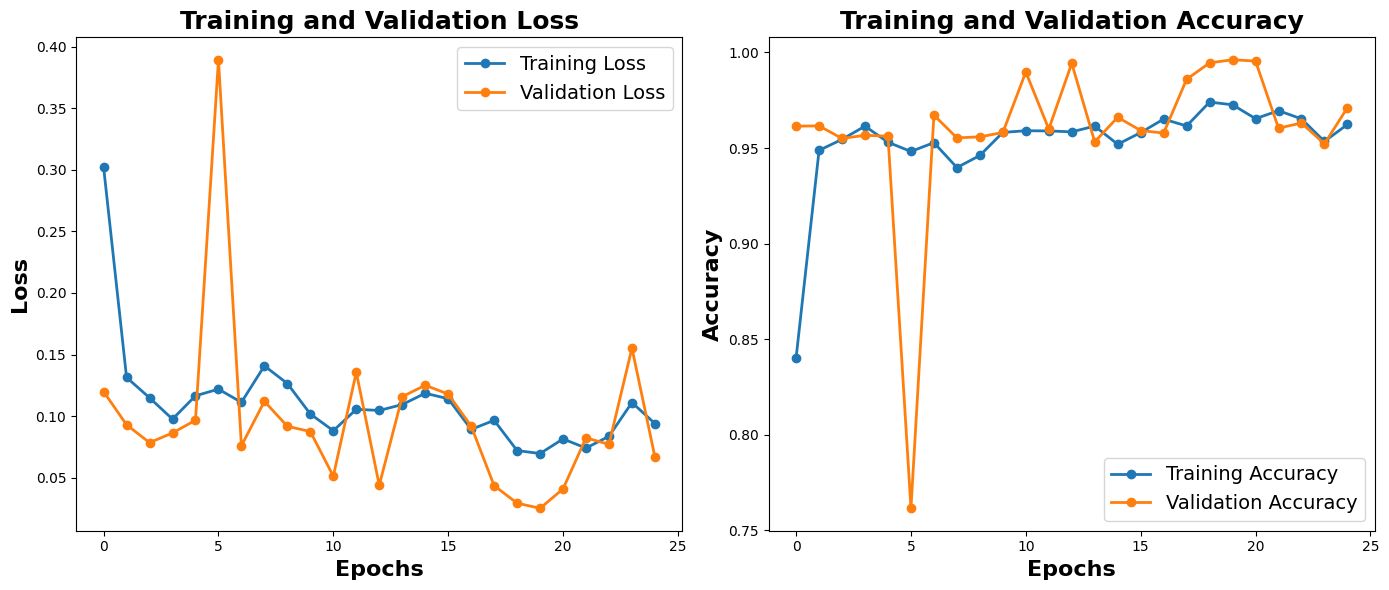

In [ ]:
import matplotlib.pyplot as plt

def plot_model_history(history):
    plt.figure(figsize=(14, 6))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2, marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='o')
    plt.title('Training and Validation Loss', fontsize=18, fontweight='bold')
    plt.xlabel('Epochs', fontsize=16, fontweight='bold')
    plt.ylabel('Loss', fontsize=16, fontweight='bold')
    plt.legend(fontsize=14)

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='o')
    plt.title('Training and Validation Accuracy', fontsize=18, fontweight='bold')
    plt.xlabel('Epochs', fontsize=16, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=16, fontweight='bold')
    plt.legend(fontsize=14)

    plt.tight_layout()
    plt.show()

# Call the function to plot the model history
plot_model_history(history)


**RANDOM FOREST CLASSIFIER**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

data = pd.read_csv("/content/task_offloading_dataset.csv")

X = data.drop(columns=['Offloading_Decision'])
y = data['Offloading_Decision']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
import pickle
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)

# Save the model
rf_model_path = "random_forest_model.pkl"
with open(rf_model_path, "wb") as f:
    pickle.dump(rf_model, f)

# Get the file size of the saved model
rf_model_size = os.path.getsize(rf_model_path) / 1024  # Size in KB
print(f"Random Forest model size: {rf_model_size:.2f} KB")

# Optionally, reduce the model size by decreasing estimators
small_rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
small_rf_model.fit(X_train, y_train)

# Save the smaller Random Forest model
small_rf_model_path = "small_random_forest_model.pkl"
with open(small_rf_model_path, "wb") as f:
    pickle.dump(small_rf_model, f)

# Get the file size of the smaller model
small_rf_model_size = os.path.getsize(small_rf_model_path) / 1024  # Size in KB
print(f"Smaller Random Forest model size: {small_rf_model_size:.2f} KB")
print(f"Reduction in size: {rf_model_size - small_rf_model_size:.2f} KB ({((rf_model_size - small_rf_model_size) / rf_model_size) * 100:.2f}%)")

# Evaluate the smaller model's accuracy
small_y_pred = small_rf_model.predict(X_test)
small_accuracy = accuracy_score(y_test, small_y_pred)
print(f"Smaller Random Forest Accuracy: {small_accuracy:.4f}")

Random Forest Accuracy: 0.9983986251611139
Random Forest model size: 16589.21 KB
Smaller Random Forest model size: 1748.00 KB
Reduction in size: 14841.21 KB (89.46%)
Smaller Random Forest Accuracy: 0.9969


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print the results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

print("Classification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 0.9983986251611139
Precision: 0.9983985855827566
Recall: 0.9983986251611139
F1-Score: 0.9983986036871392
Classification Report:
                precision    recall  f1-score   support

   Edge Cloud       1.00      1.00      1.00     17660
Mobile Device       1.00      1.00      1.00     33546

     accuracy                           1.00     51206
    macro avg       1.00      1.00      1.00     51206
 weighted avg       1.00      1.00      1.00     51206



In [ ]:
# import shap

# # Create a SHAP explainer
# explainer = shap.TreeExplainer(rf_model,X_train)

# shap_values = explainer.shap_values(X_test)

# shap.summary_plot(shap_values[1], X_test, feature_names=data.columns[:-1])

# shap.initjs()
# shap.force_plot(shap_values[1][0], X_test[0], feature_names=data.columns[:-1])


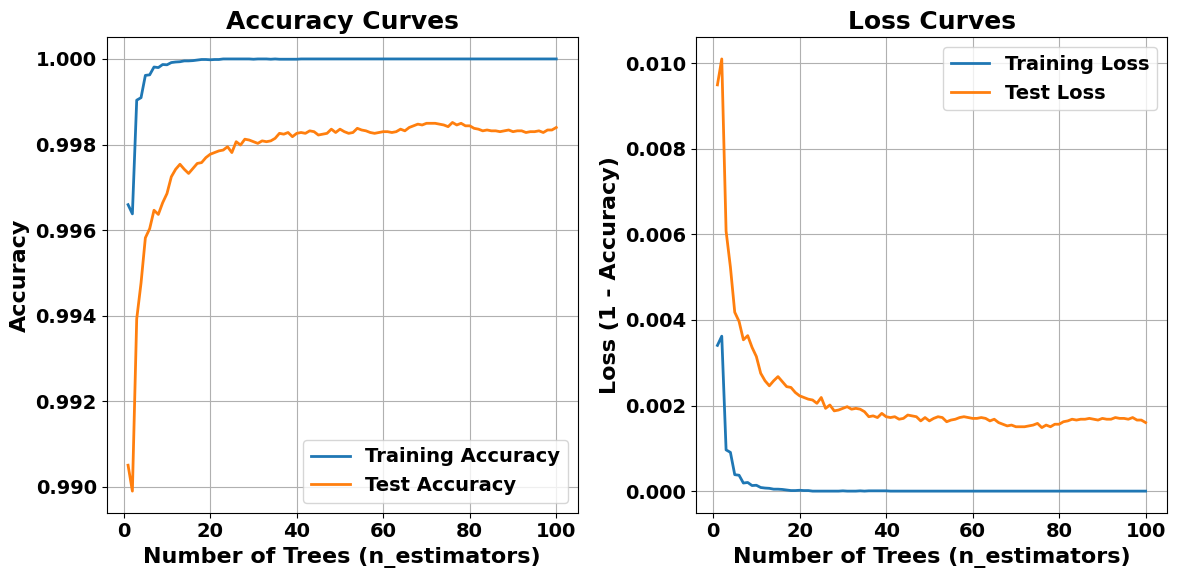

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Assuming X_train, X_test, y_train, y_test are already defined
# Range of n_estimators to test
n_estimators_range = range(1, 101)  # Vary from 1 to 100 trees
train_accuracies = []
test_accuracies = []

for n in n_estimators_range:
    rf_model = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_model.fit(X_train, y_train)

    # Evaluate on training and test data
    train_accuracies.append(accuracy_score(y_train, rf_model.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, rf_model.predict(X_test)))

# Calculate "loss" as 1 - accuracy
train_losses = [1 - acc for acc in train_accuracies]
test_losses = [1 - acc for acc in test_accuracies]

# Set font properties globally
plt.rcParams.update({
    'font.size': 14,       # Larger font size
    'font.weight': 'bold'  # Bold text
})

# Plot accuracy curves
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(n_estimators_range, train_accuracies, label='Training Accuracy', linewidth=2)
plt.plot(n_estimators_range, test_accuracies, label='Test Accuracy', linewidth=2)
plt.xlabel('Number of Trees (n_estimators)', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=16, fontweight='bold')
plt.title('Accuracy Curves', fontsize=18, fontweight='bold')
plt.legend(fontsize=14)
plt.grid(True)

# Plot loss curves
plt.subplot(1, 2, 2)
plt.plot(n_estimators_range, train_losses, label='Training Loss', linewidth=2)
plt.plot(n_estimators_range, test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Number of Trees (n_estimators)', fontsize=16, fontweight='bold')
plt.ylabel('Loss (1 - Accuracy)', fontsize=16, fontweight='bold')
plt.title('Loss Curves', fontsize=18, fontweight='bold')
plt.legend(fontsize=14)
plt.grid(True)

plt.tight_layout()
plt.show()


DECISION TREE


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Encode target variable
label_encoder = LabelEncoder()
data['Offloading_Decision'] = label_encoder.fit_transform(data['Offloading_Decision'])

# Separate features and target variable
X = data.drop(columns=['Offloading_Decision'])
y = data['Offloading_Decision']

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train a Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
training_accuracies = []
losses = []

# Train and record accuracy for each epoch-like iteration
for i in range(1, 21):  # Simulating epoch-like iterations
    clf.set_params(max_depth=i)  # Adjusting tree depth incrementally
    clf.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, clf.predict(X_train))
    loss = 1 - train_accuracy
    training_accuracies.append(train_accuracy)
    losses.append(loss)


training_accuracies

[0.8542213379877699,
 0.8723040681565746,
 0.9582138192825496,
 0.9582138192825496,
 0.9738248971670593,
 0.976009715729473,
 0.9856949309768214,
 0.990918966422146,
 0.9960331506548353,
 0.997302542445288,
 0.9989930305508428,
 0.9995422866140194,
 0.9998291203359005,
 0.9999267658582431,
 0.9999816914645607,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

In [ ]:
# Evaluate accuracy on the training and test sets with optimal depth
optimal_depth = training_accuracies.index(max(training_accuracies)) + 1
clf.set_params(max_depth=optimal_depth)
clf.fit(X_train, y_train)

train_accuracy = accuracy_score(y_train, clf.predict(X_train))
test_accuracy = accuracy_score(y_test, clf.predict(X_test))

train_accuracy, test_accuracy


(1.0, 0.9984376907115831)

In [ ]:
# Limit tree depth for visualization
example_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
example_clf.fit(X_train, y_train)

# Ensure class names are strings
class_names = list(map(str, label_encoder.classes_))

# Visualize the simplified tree
plt.figure(figsize=(12, 8))  # Smaller size for a simplified tree
plot_tree(
    example_clf,
    feature_names=X.columns,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Simplified Decision Tree Visualization", fontsize=14)
plt.show()

# Optional: Text rules for this smaller tree
example_tree_rules = export_text(example_clf, feature_names=list(X.columns))
print(example_tree_rules)


NameError: name 'plot_tree' is not defined

<Figure size 1200x800 with 0 Axes>

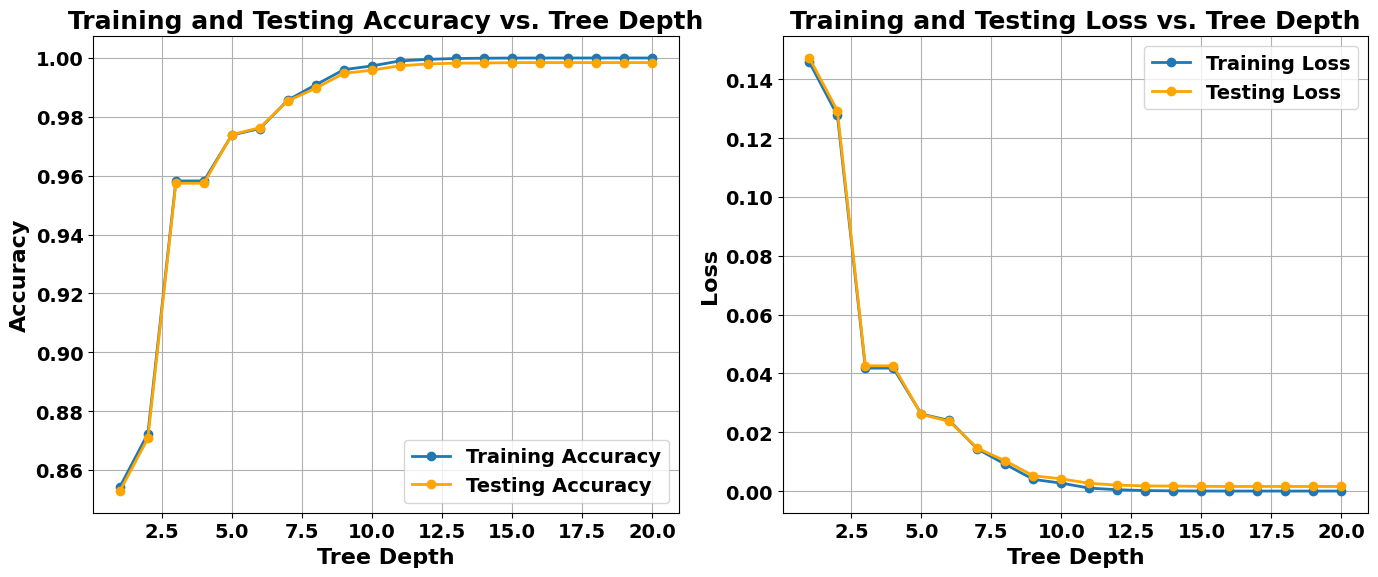

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Assuming clf, X_train, y_train, X_test, y_test are already defined

# Initialize lists to store accuracies and losses
train_accuracies = []
test_accuracies = []
loss_train_accuracies = []
loss_test_accuracies = []

# Loop through tree depths
for i in range(1, 21):
    clf.set_params(max_depth=i)
    clf.fit(X_train, y_train)

    # Calculate training accuracy and loss
    train_accuracy = accuracy_score(y_train, clf.predict(X_train))
    loss_train = 1 - train_accuracy
    train_accuracies.append(train_accuracy)
    loss_train_accuracies.append(loss_train)

    # Calculate testing accuracy and loss
    test_accuracy = accuracy_score(y_test, clf.predict(X_test))
    loss_test = 1 - test_accuracy
    test_accuracies.append(test_accuracy)
    loss_test_accuracies.append(loss_test)

# Set global font properties
plt.rcParams.update({
    'font.size': 14,       # Larger font size
    'font.weight': 'bold'  # Bold text
})

# Create figure for accuracy plots
plt.figure(figsize=(14, 6))

# Plot training and testing accuracy
plt.subplot(1, 2, 1)
plt.plot(range(1, 21), train_accuracies, marker='o', label='Training Accuracy', linewidth=2)
plt.plot(range(1, 21), test_accuracies, marker='o', label='Testing Accuracy', color='orange', linewidth=2)
plt.xlabel('Tree Depth', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=16, fontweight='bold')
plt.title('Training and Testing Accuracy vs. Tree Depth', fontsize=18, fontweight='bold')
plt.legend(fontsize=14)
plt.grid(True)

# Plot training and testing loss
plt.subplot(1, 2, 2)
plt.plot(range(1, 21), loss_train_accuracies, marker='o', label='Training Loss', linewidth=2)
plt.plot(range(1, 21), loss_test_accuracies, marker='o', label='Testing Loss', color='orange', linewidth=2)
plt.xlabel('Tree Depth', fontsize=16, fontweight='bold')
plt.ylabel('Loss', fontsize=16, fontweight='bold')
plt.title('Training and Testing Loss vs. Tree Depth', fontsize=18, fontweight='bold')
plt.legend(fontsize=14)
plt.grid(True)

plt.tight_layout()
plt.show()
